# Preface

In this notebook, we will explore the application of PCA for a variety of practical problems, including
   * Feature extraction and dimensionality reduction
   * Denoising
   * Clustering and measuring similarity
   
We will also demonstrate basic usage of `sklearn.decomposition.PCA`, as well as building autoencoders with `PyTorch`. Incidentally, we will also use the `kaggle` API to download some public datasets.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_context('notebook', font_scale=1.25, rc={"lines.linewidth": 2.5})
sns.set_style("darkgrid")
np.random.seed(374)  # For reproducibility

# PCA and Autoecnoders on MNIST

In this section, we perform principal component analysis and autoencoders on the MNIST hand-written digits dataset that we have seen before.

In [3]:
def plot_images(x, nrow=2, ncol=4, randomize=True):
    """
    Plot Images
    """
    fig, ax = plt.subplots(nrow, ncol, figsize=(5*ncol, 4*nrow))
    num_samples = x.shape[0]
    if x.ndim == 2:
        img_size = int(round(np.sqrt(x.shape[-1])))
        assert img_size**2 == x.shape[-1]  # Check Square Image
        x = x.reshape(-1, img_size, img_size)
    for k, a in enumerate(ax.ravel()):
        if randomize:
            j = np.random.choice(num_samples)
        else:
            j = k
        a.imshow(x[j])
        a.set_xticks([])
        a.set_yticks([])

We import MNIST using [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html). We use PyTorch for implementing autoencoder.

In [4]:
import torch
from torchvision.datasets import MNIST

#torch.manual_seed(473)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
#print(f"PyTorch {torch.__version__} | device: {device}")

In [5]:
mnist_train = MNIST(root="./data", train=True, download=True)
mnist_test = MNIST(root="./data", train=False, download=True)
images_train = mnist_train.data.numpy().astype(np.float32) / 255.0
images_test = mnist_test.data.numpy().astype(np.float32) / 255.0

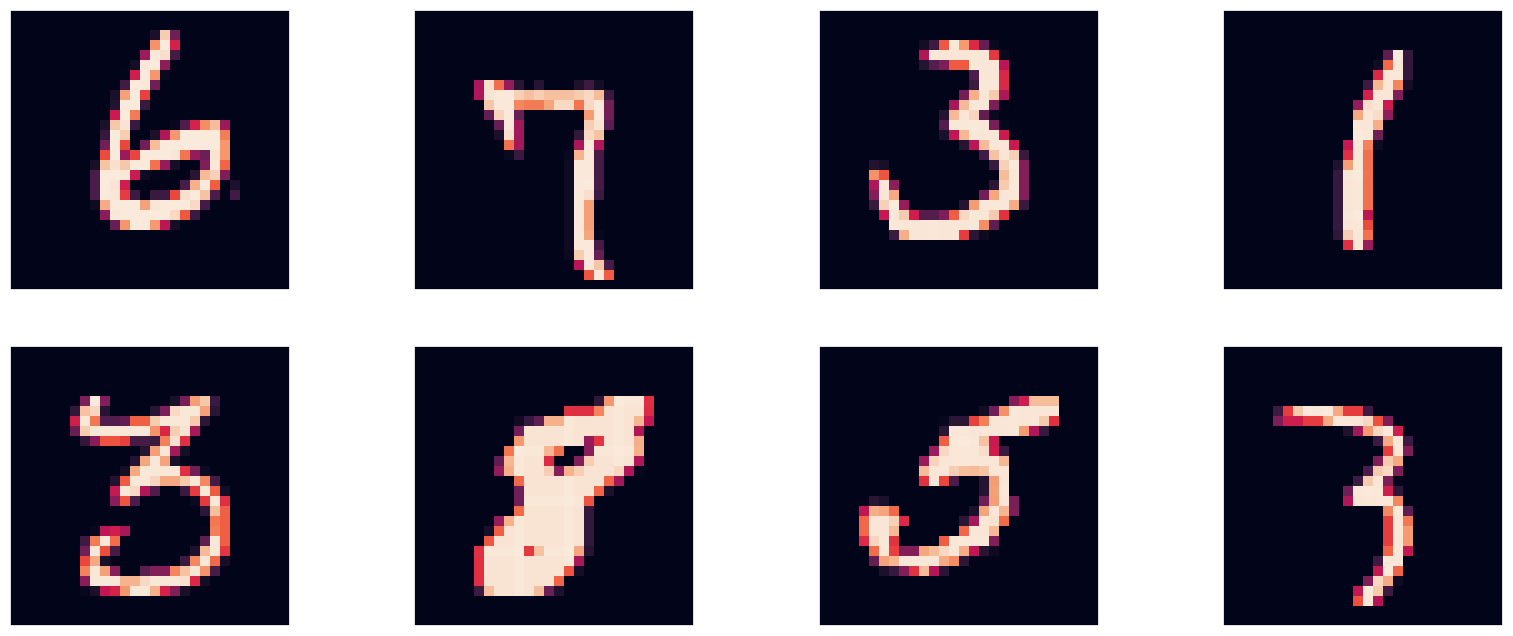

In [6]:
plot_images(images_train)

## PCA

Let us now perform PCA. For demonstration we will only work with the training set and evaluate our performance on the test set. In general, depending on the task at hand this splitting may be unnecesssary. For example, if we are interested in compression or feature extraction then there is no need for a train-test split.

Here, we will use the `sklearn.decomposition.PCA` class to perform PCA.

In [7]:
from sklearn.decomposition import PCA

In [8]:
pca = PCA(n_components=64)
pca.fit(images_train.reshape(-1, 784))

/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",64
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

### Eigenvalues / Explained Variance

Now, we plot the eigenvalues of the sample covariance matrix (equivalently, the singular values of the data matrix). Note that they are arranged in decreasing order and accessible from the `explained_variance_` attribute.

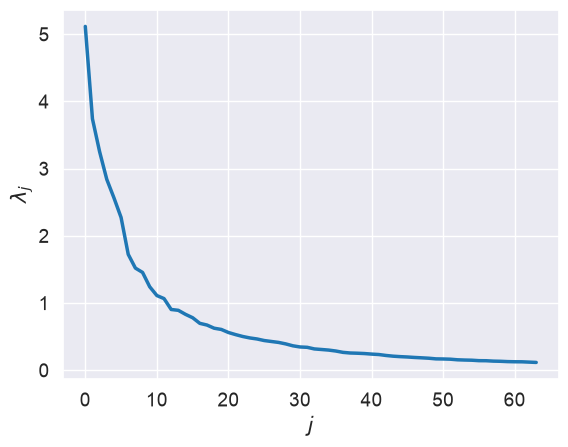

In [9]:
plt.plot(pca.explained_variance_)
plt.xlabel(r'$j$')
plt.ylabel(r'$\lambda_j$');

We can also see what principal component axes are identified. These are accessible through the `components_` attribute. 

**Remark.**
Unlike our notation in the notes, here each eigenvector is a *row*, instead of a *column* of the matrix `pca.components_`. In other words, `pca.components_(j)` is the $j^\text{th}$ eigenvector. 

### Principal Component Axes

(64, 784)

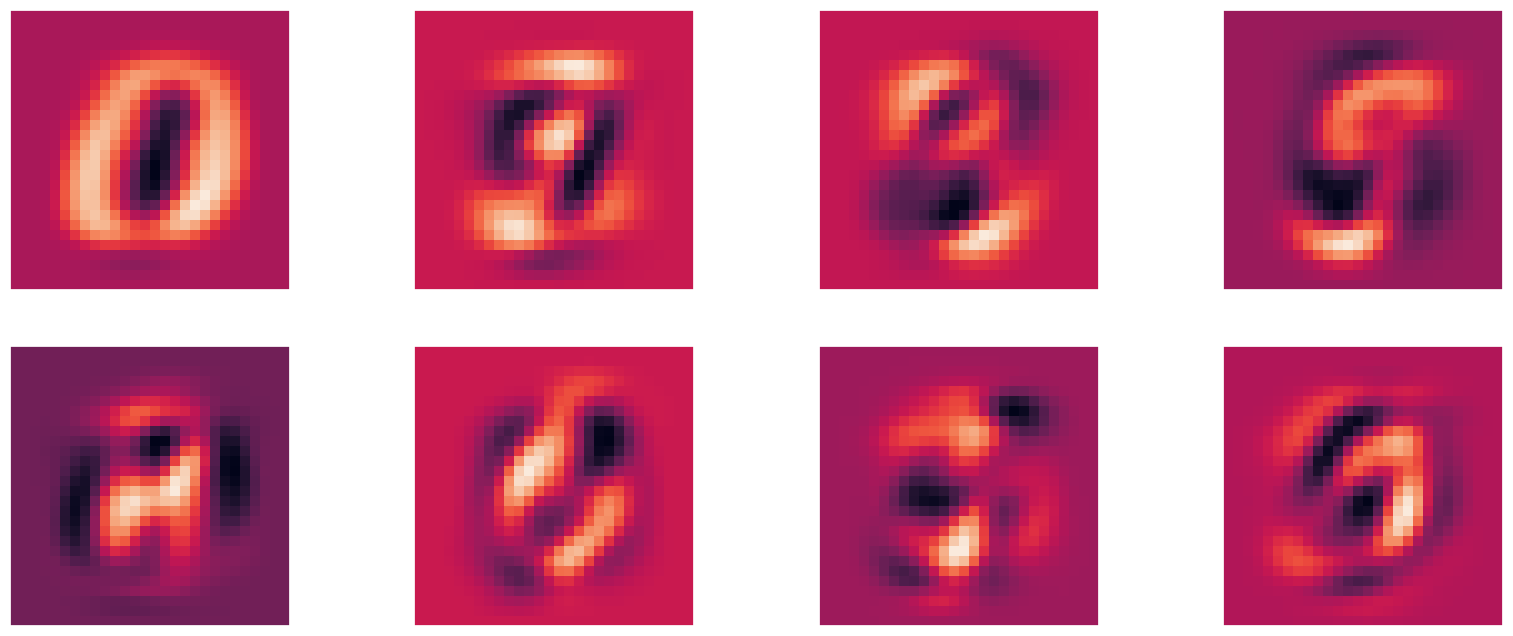

In [10]:
plot_images(pca.components_, randomize=False)
pca.components_.shape

### Reconstruction using Principal Component Scores

We demonstrate how to get back our image. As discussed, the PCA compression gives the rescaled latents
$$
    Z_m = X U_m
$$
Here, the latents are computed by calling `pca.transform`.

The inverse transform is given by
$$
    X'_m = Z_m U_m^T
$$
This gives us the reconstructed image. Here, it is computed using `pca.inverse_transform`.

In [11]:
scores = pca.transform(images_test.reshape(-1, 784))
scores.shape
images_recon = pca.inverse_transform(scores)

/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:159: RuntimeWarning: divide by zero encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components_.T
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:159: RuntimeWarning: overflow encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components

Let us see how well we did!

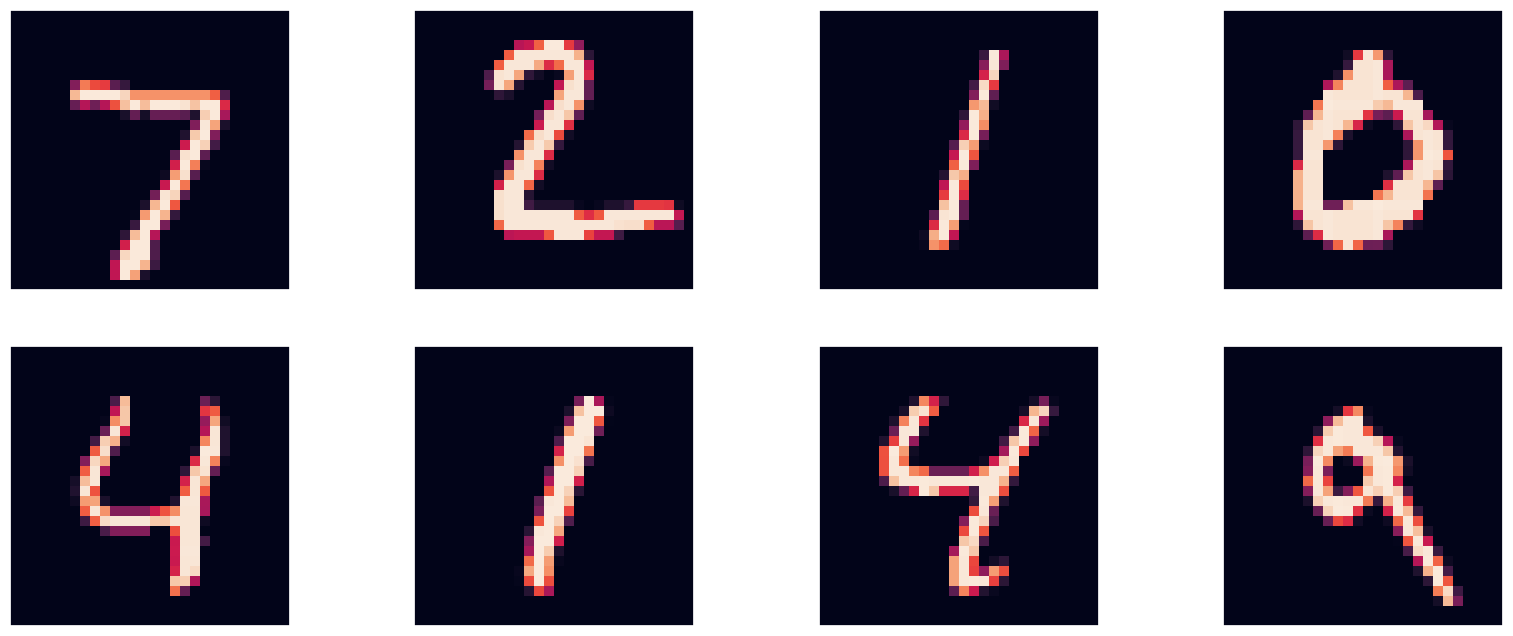

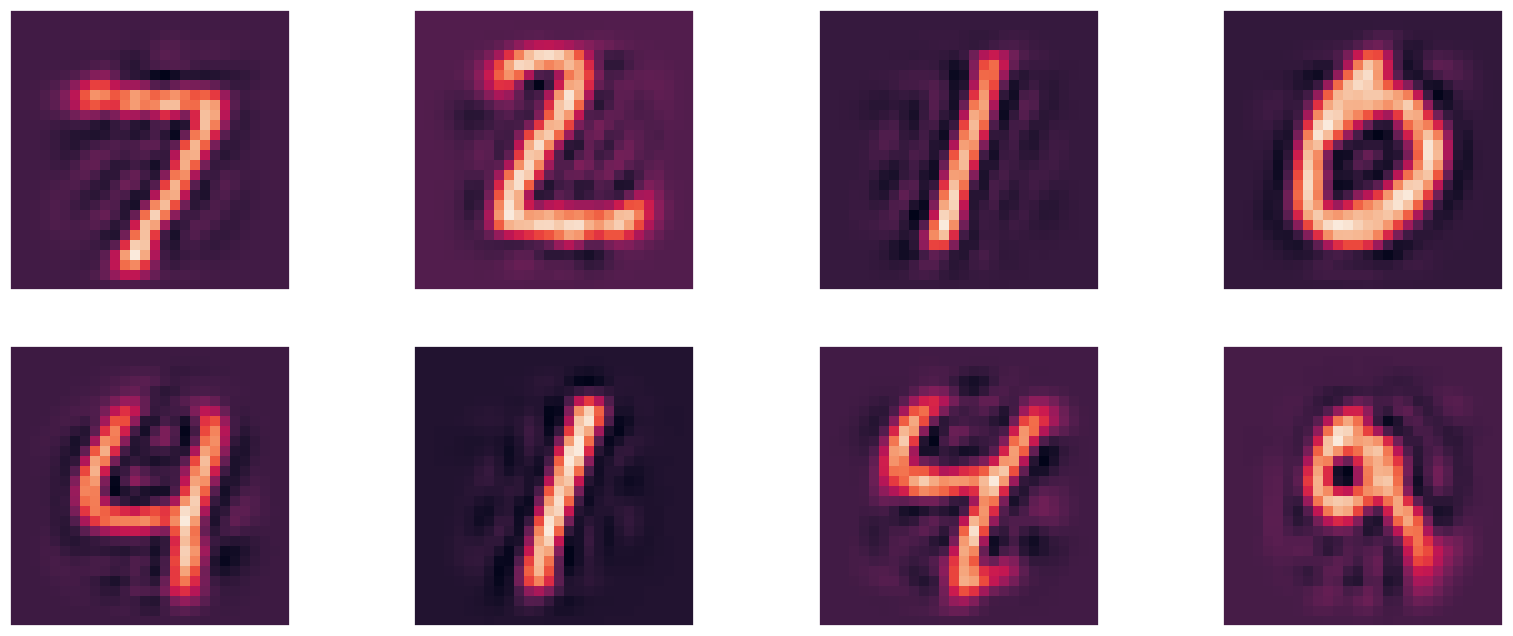

In [12]:
plot_images(images_test, randomize=False, nrow=2)
plot_images(images_recon, randomize=False, nrow=2)

## Autoencoder with Neural Networks

Let us now try to do the same compression, but with a nonlinear neural network as encoder and decoder functions.

In [13]:
from torch import nn
from torch.utils.data import DataLoader

In [19]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid(),
        )

    def forward(self, images):
        compressed_images = self.encoder(images)
        return self.decoder(compressed_images)

    def fit(self, images, batch_size, epochs):
        """Learn to reconstruct the training images."""
        training_images = torch.as_tensor(images.reshape(-1, 784), dtype=torch.float32)
        training_batches = DataLoader(training_images, batch_size=batch_size, shuffle=True)
        device = next(self.parameters()).device
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        loss_function = nn.BCELoss()

        self.train()  # Enable training mode; fit() performs the actual learning.
        for epoch in range(epochs):
            total_loss = 0.0
            for image_batch in training_batches:
                image_batch = image_batch.to(device)
                optimizer.zero_grad()
                reconstructed_images = self(image_batch)
                loss = loss_function(reconstructed_images, image_batch)
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * len(image_batch)

            average_loss = total_loss / len(training_images)
            print(f"Epoch {epoch + 1:2d}/{epochs} - reconstruction loss: {average_loss:.4f}")

    def predict(self, images, batch_size=128):
        """Reconstruct images without changing the learned weights."""
        images = torch.as_tensor(images.reshape(-1, 784), dtype=torch.float32)
        device = next(self.parameters()).device
        self.eval()
        reconstructions = []
        with torch.inference_mode():
            for image_batch in images.split(batch_size):
                reconstructed_images = self(image_batch.to(device))
                reconstructions.append(reconstructed_images.cpu())
        return torch.cat(reconstructions).numpy()

In [20]:
autoencoder = Autoencoder().to(device)

In [21]:
autoencoder.fit(images_train, batch_size=128, epochs=10)

Epoch  1/10 - reconstruction loss: 0.2158
Epoch  2/10 - reconstruction loss: 0.1299
Epoch  3/10 - reconstruction loss: 0.1135
Epoch  4/10 - reconstruction loss: 0.1049
Epoch  5/10 - reconstruction loss: 0.0991
Epoch  6/10 - reconstruction loss: 0.0953
Epoch  7/10 - reconstruction loss: 0.0926
Epoch  8/10 - reconstruction loss: 0.0906
Epoch  9/10 - reconstruction loss: 0.0888
Epoch 10/10 - reconstruction loss: 0.0875


In [22]:
images_recon_ae = autoencoder.predict(images_test)

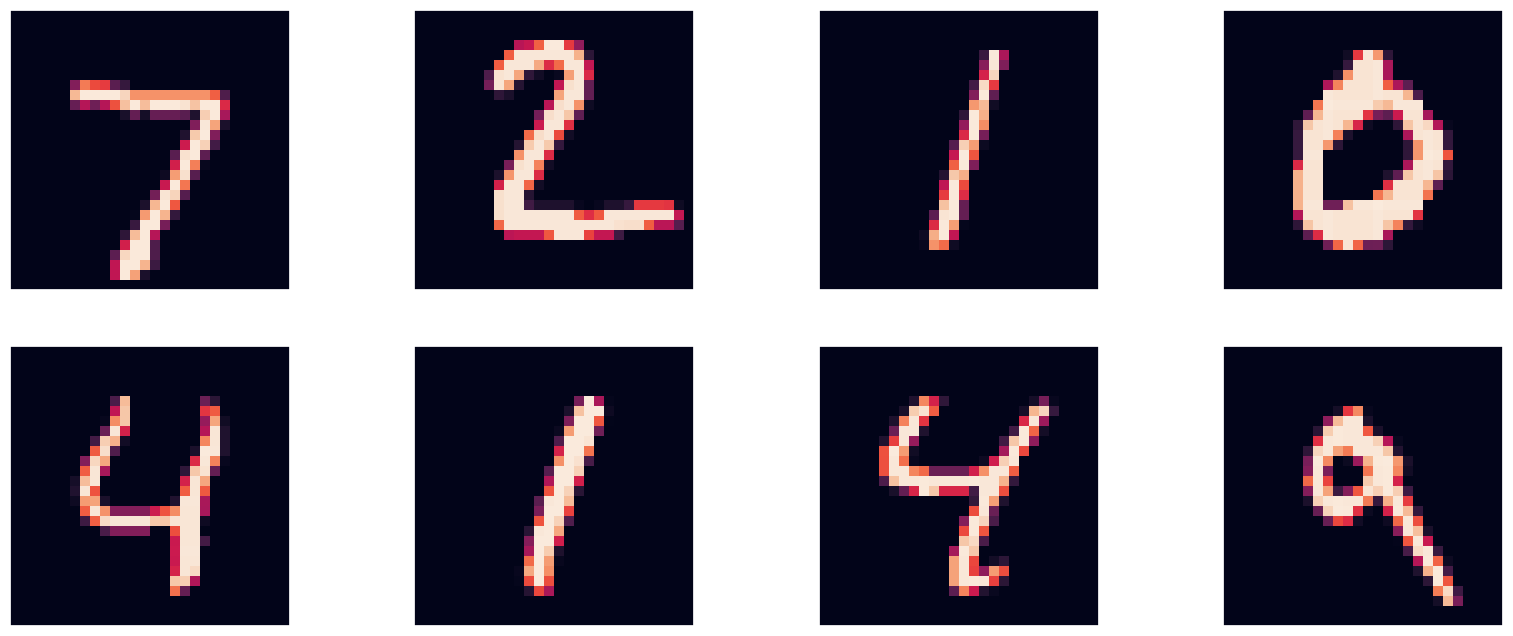

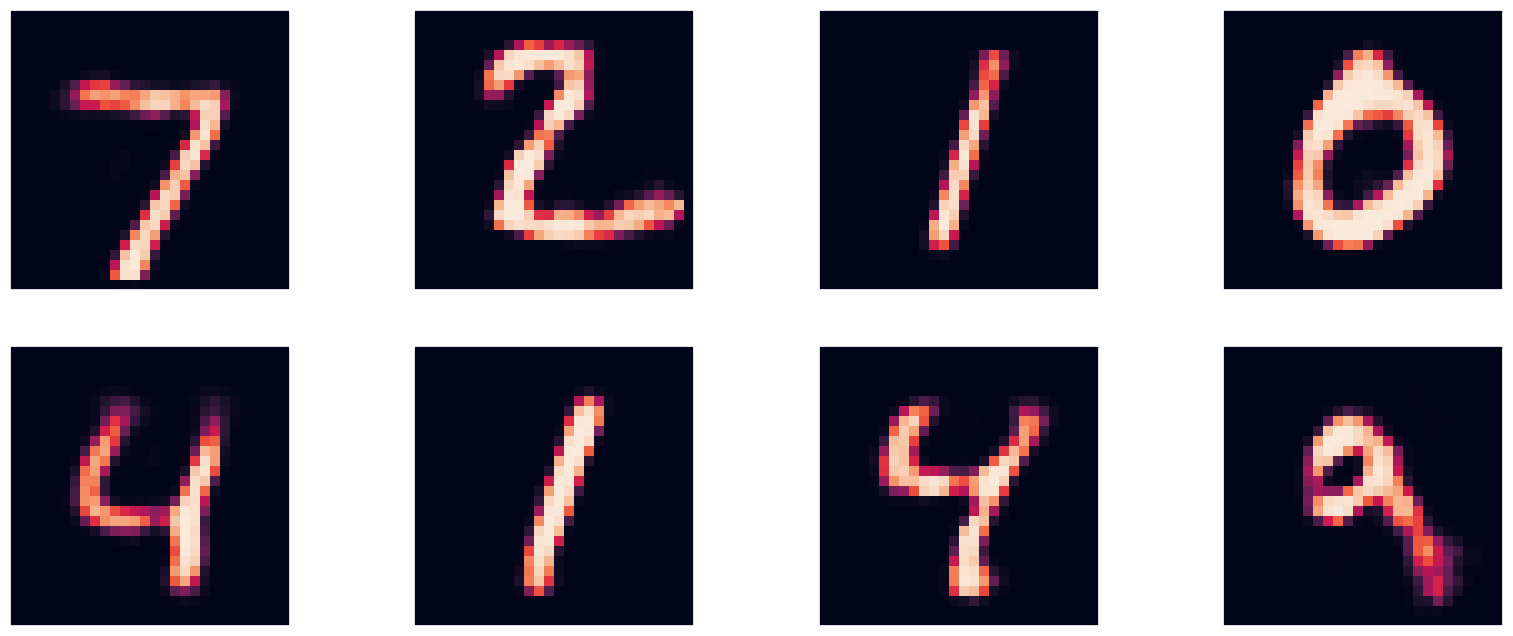

In [23]:
plot_images(images_test, randomize=False, nrow=2)
plot_images(images_recon_ae, randomize=False, nrow=2)

## Denoising using PCA and AE

Now, let us see another use for PCA and Autoencoders: denoising.

In [24]:
def add_noise_and_clip(x):
    """
    Add Gaussian noise to images
    """
    x = x + 0.2 * np.random.normal(size=x.shape)
    x = np.maximum(x, 0.0)
    x = np.minimum(x, 1.0)
    return x

We first create some noisy images.

In [25]:
images_train_noisy = add_noise_and_clip(images_train)
images_test_noisy = add_noise_and_clip(images_test)

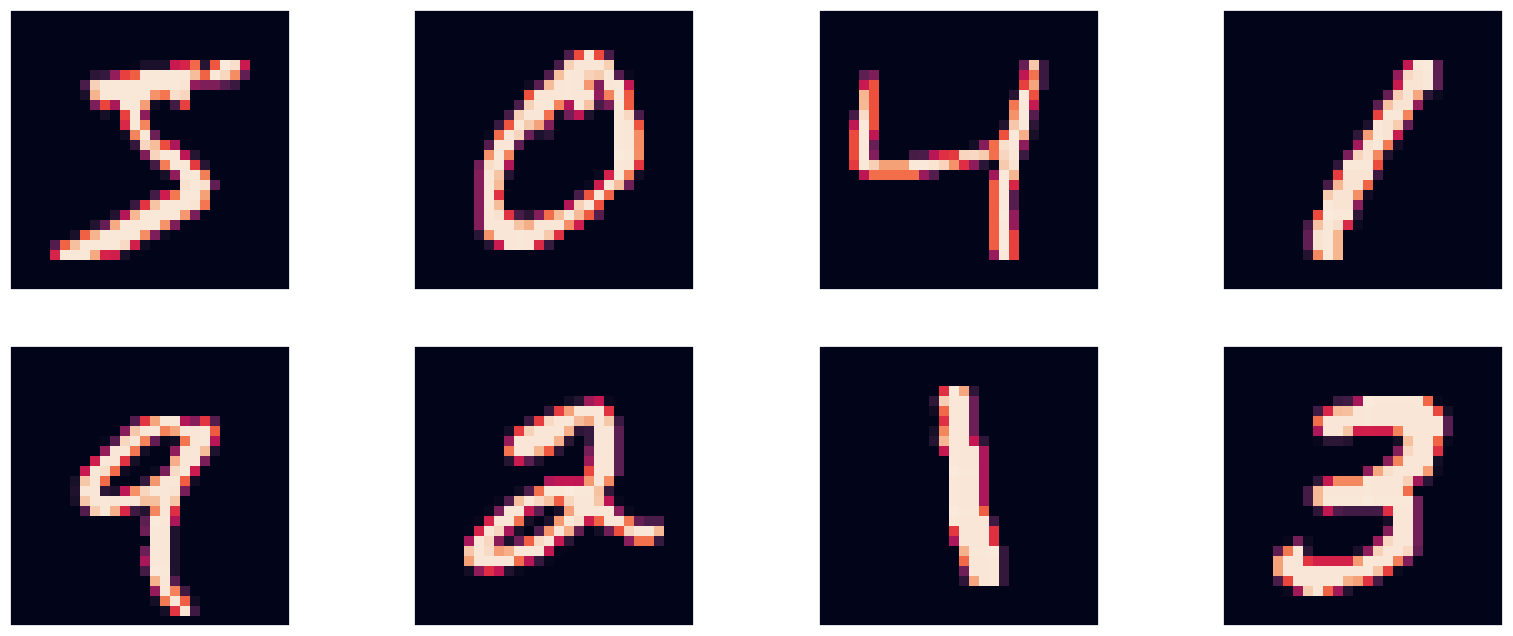

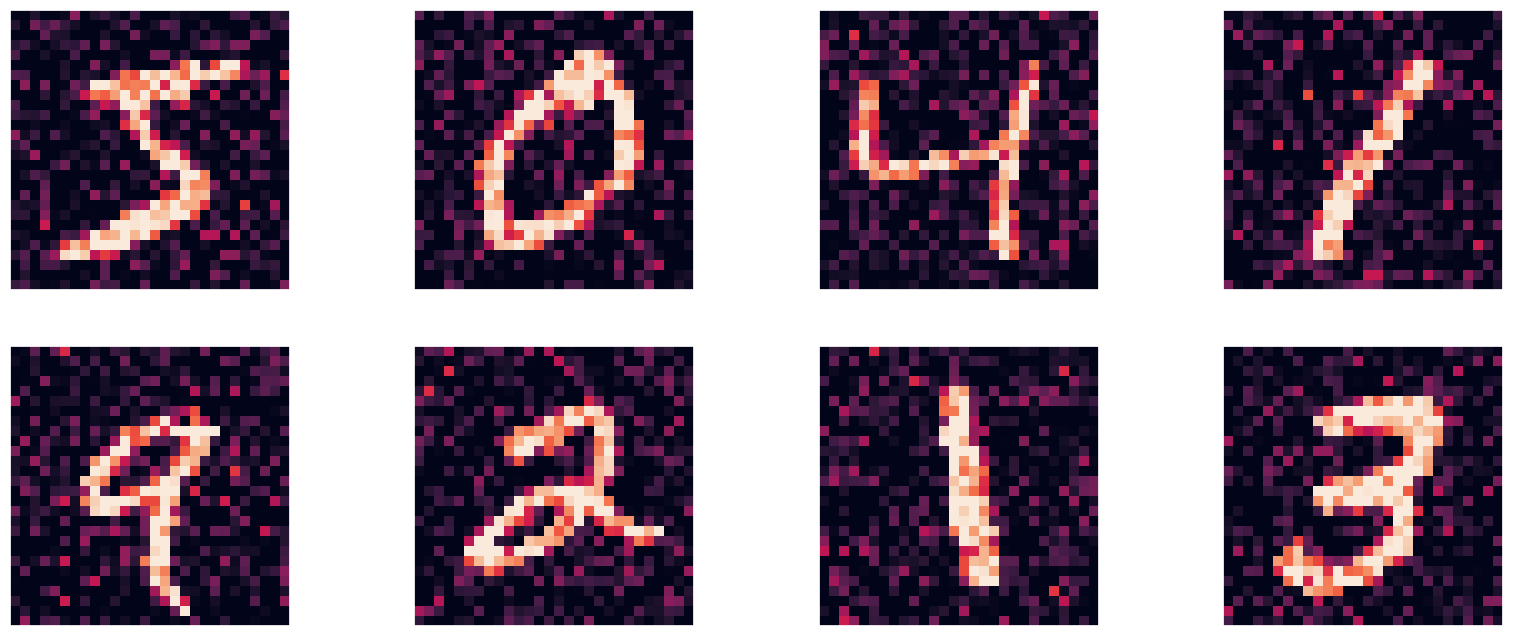

In [26]:
plot_images(images_train, randomize=False, nrow=2)
plot_images(images_train_noisy, randomize=False, nrow=2)

### PCA

Using the PCA, we can transform the noisy image into the latent space and then back. Because this encoding-decoding scheme is lossy, it actually drops many unimportant features in the data, including the noise!

In [27]:
scores = pca.transform(images_test_noisy.reshape(-1, 784))
images_recon = pca.inverse_transform(scores)

/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:159: RuntimeWarning: divide by zero encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components_.T
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:159: RuntimeWarning: overflow encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components

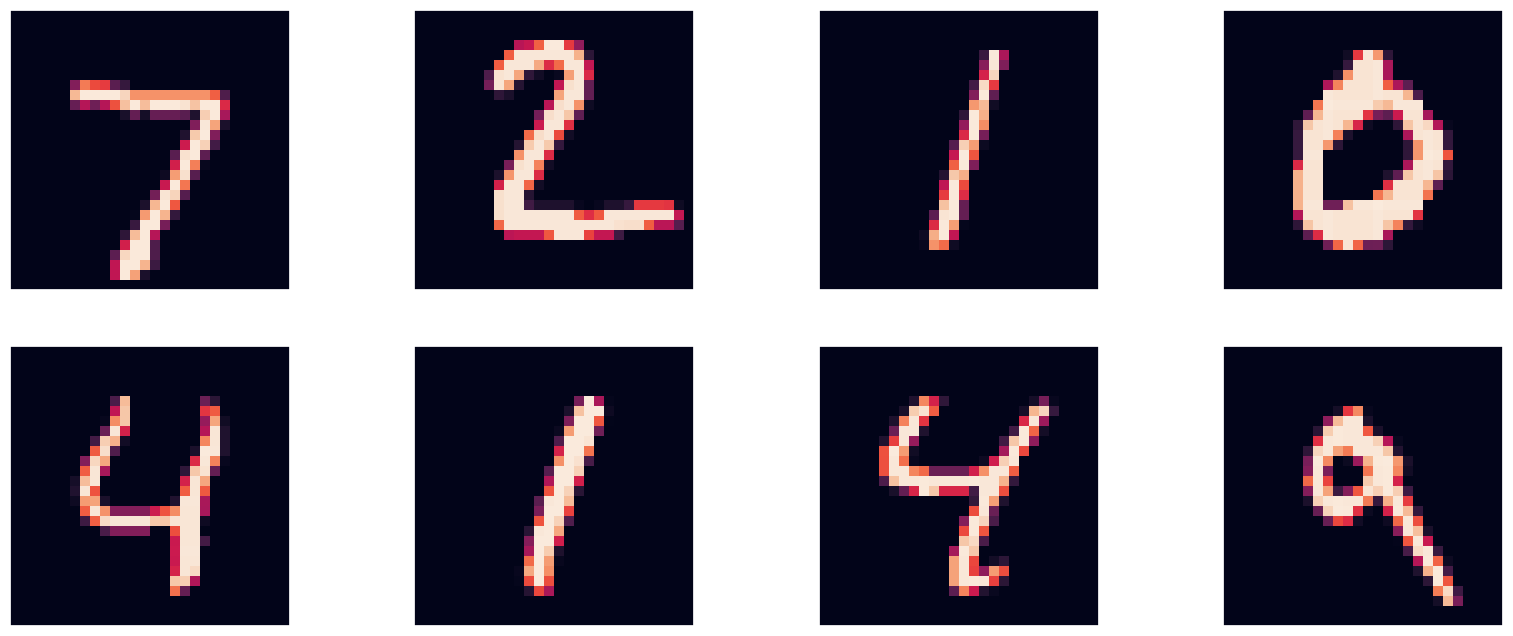

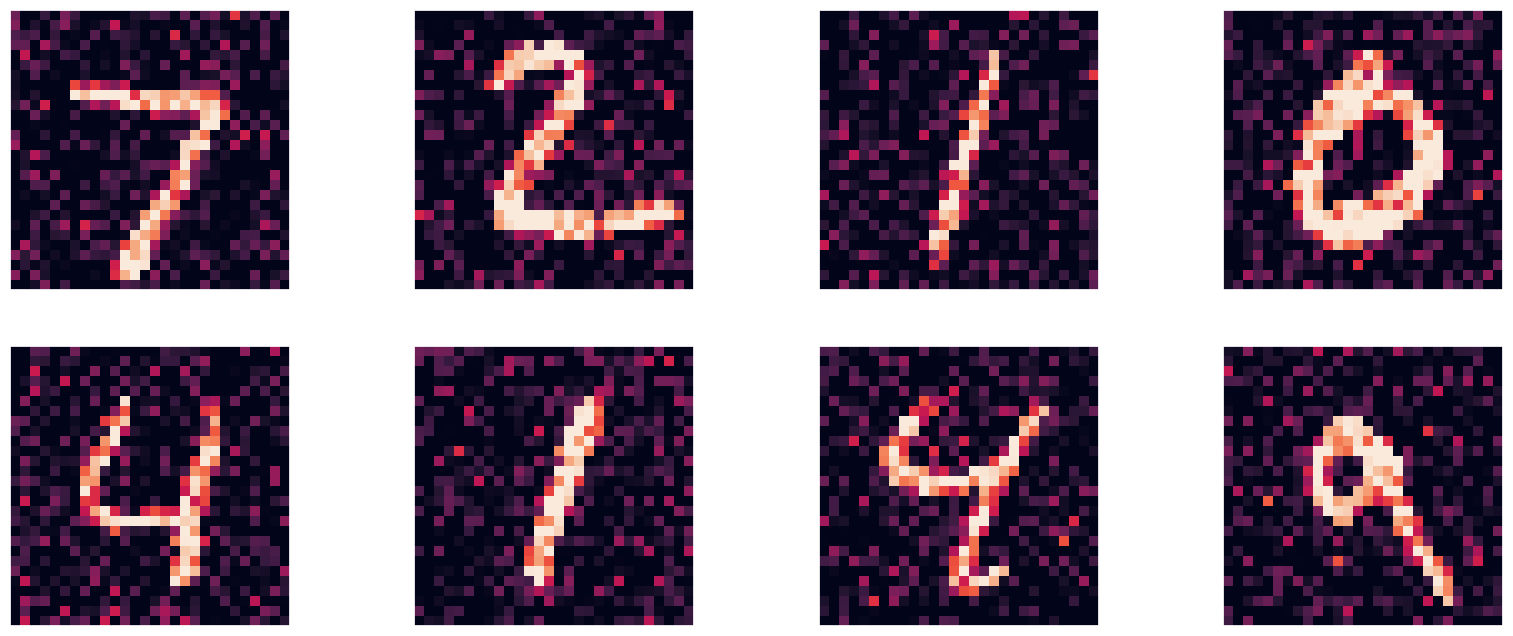

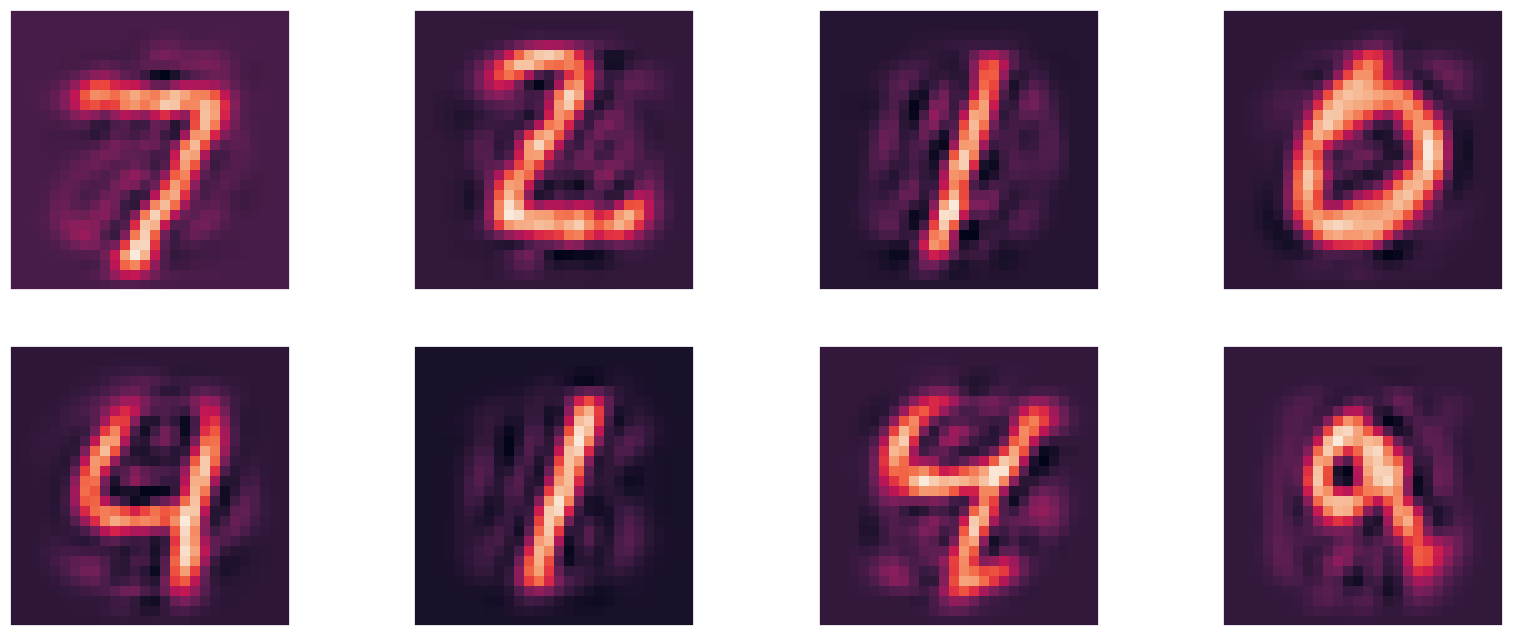

In [28]:
plot_images(images_test, randomize=False, nrow=2)
plot_images(images_test_noisy, randomize=False, nrow=2)
plot_images(images_recon, randomize=False, nrow=2)

### AutoEncoder

We can reconstruct noisy images with the same `predict()` method.

In [29]:
images_recon_ae = autoencoder.predict(images_test_noisy)

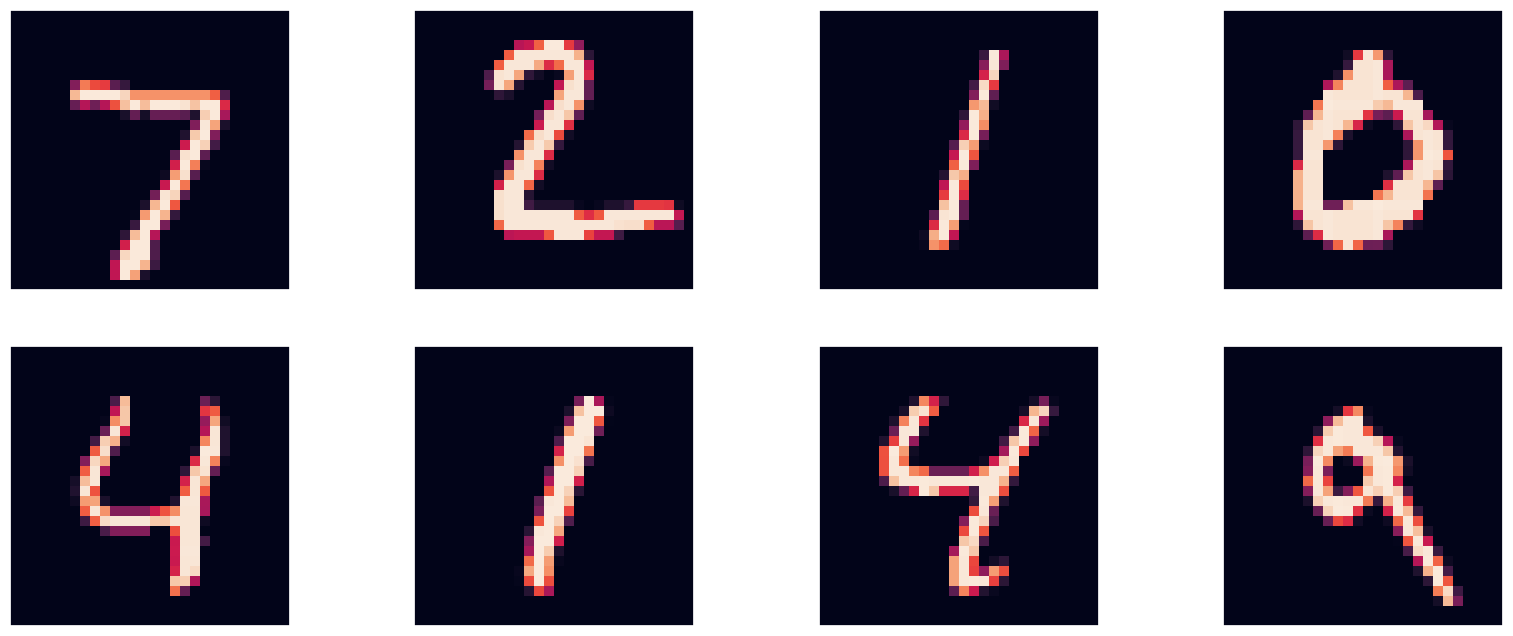

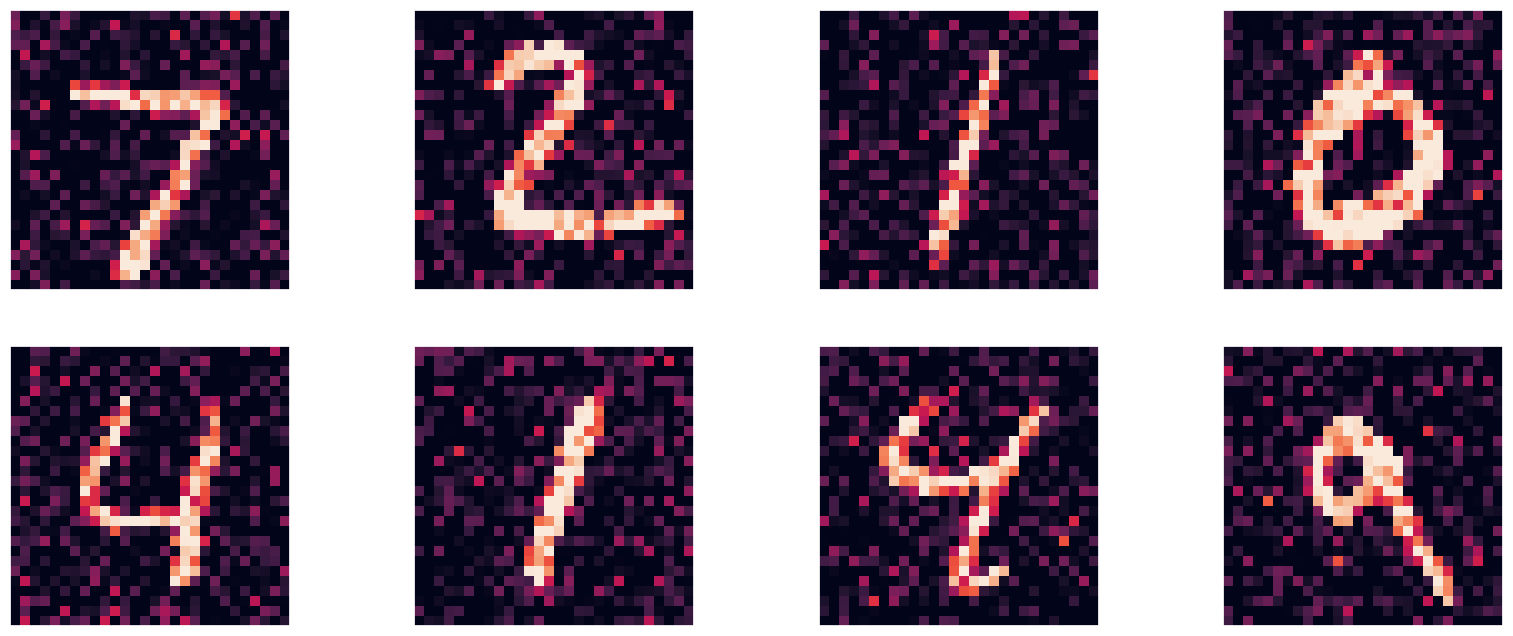

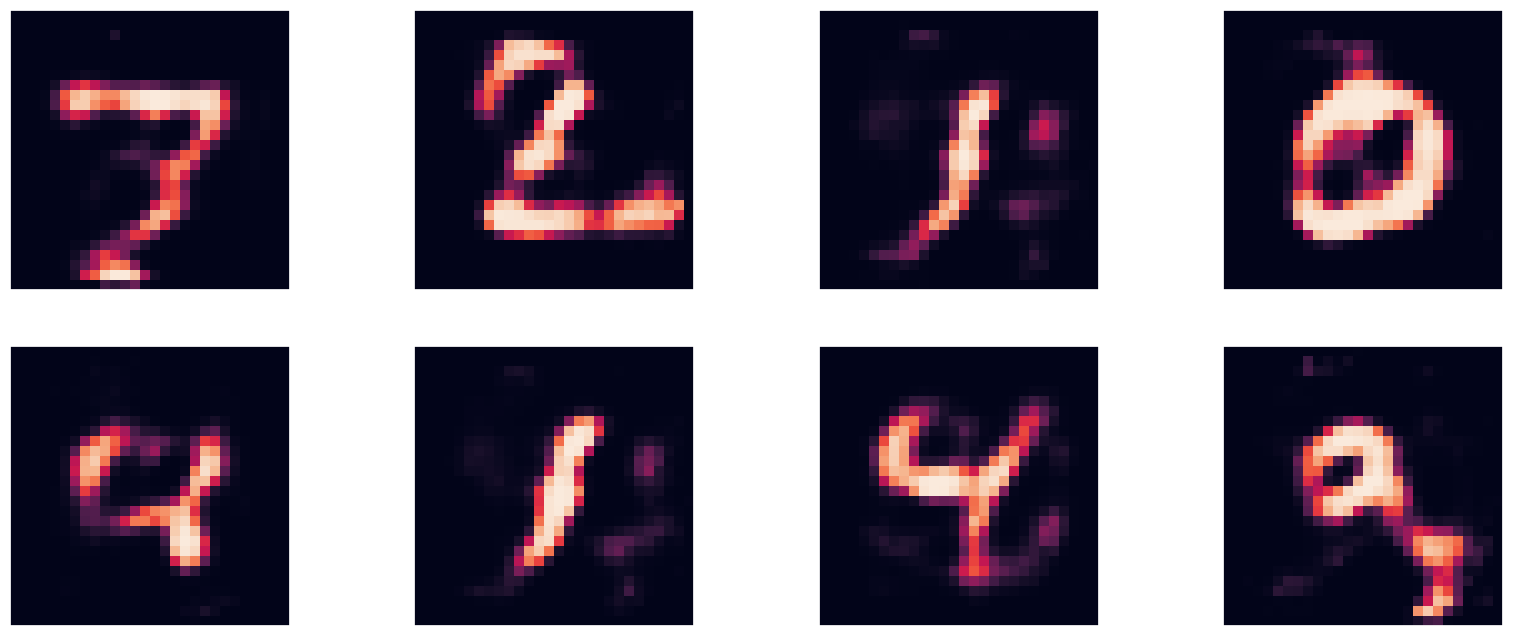

In [30]:
plot_images(images_test, randomize=False, nrow=2)
plot_images(images_test_noisy, randomize=False, nrow=2)
plot_images(images_recon_ae, randomize=False, nrow=2)

**Remark.**
To obtain better performance, you may want to train the autoencoder with noisy inputs and clean outputs in the data. This is called *denoising autoencoders* and are very useful to remove noise, provided that you have noisy samples from the same distribution.

# PCA and Data Normalization

We are going to demonstrate the importance of data normalization in PCA using a real-world dataset. 

This is a dataset from `kaggle` which contains [sales from supermarkets](https://www.kaggle.com/datasets/faresashraf1001/supermarket-sales) in three cities in Myanmar. You can import it using the `kaggle` API. Follow the instructions [here](https://github.com/Kaggle/kaggle-api) to set this up. This allows easy downloading of datasets from [https://www.kaggle.com/datasets](https://www.kaggle.com/datasets). Of course, you can also directly download all the data from the website, which is what we are doing here.

In [26]:
#import kaggle
#kaggle.api.authenticate()

#kaggle.api.dataset_download_files(
#    'aungpyaeap/supermarket-sales',
#    path='./data',
#    quiet=False,
#    unzip=True
#)

In [ ]:
import kaggle
kaggle.api.authenticate()
supermarket_data = pd.read_csv('data/SuperMarketAnalysis.csv')

In [28]:
#supermarket_data = pd.read_csv('./data/supermarket_sales - Sheet1.csv')

## Visualization

In [29]:
supermarket_data.head(n=10)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,Giza,Naypyitaw,Member,Female,Electronic accessories,85.39,7,29.8865,627.6165,3/25/2019,6:30:00 PM,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,Alex,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2/25/2019,2:36:00 PM,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,Giza,Naypyitaw,Member,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2/24/2019,11:38:00 AM,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,Alex,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.1460,1/10/2019,5:15:00 PM,Credit card,72.52,4.761905,3.6260,7.2
9,692-92-5582,Cairo,Mandalay,Member,Female,Food and beverages,54.84,3,8.2260,172.7460,2/20/2019,1:27:00 PM,Credit card,164.52,4.761905,8.2260,5.9


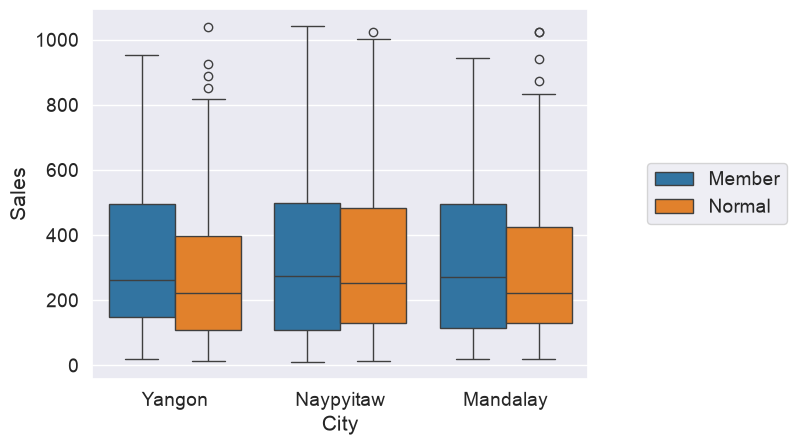

In [30]:
ax = sns.boxplot(x='City', y='Sales', data=supermarket_data, hue='Customer type')
ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), ncol=1)

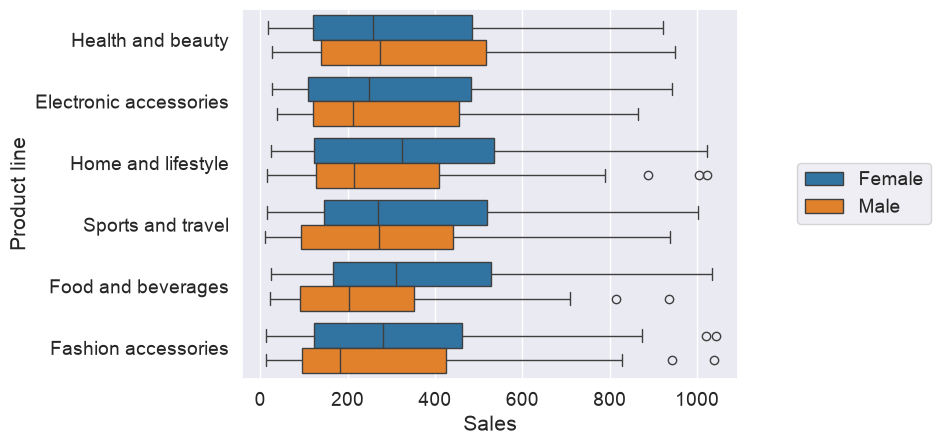

In [31]:
ax = sns.boxplot(x='Sales', y='Product line', data=supermarket_data, hue='Gender')
ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), ncol=1);

## PCA

Let us Perform PCA on the supermarket dataset to uncover some hidden relationships. We first remove some attributes for simplicity.

In [32]:
for c in ['Invoice ID', 'Branch', 'Tax 5%', 'Date', 'Time', 'gross margin percentage']:
    supermarket_data.pop(c)

supermarket_data = pd.get_dummies(supermarket_data)

In [33]:
supermarket_data

,Unit price,Quantity,Sales,cogs,gross income,Rating,City_Mandalay,City_Naypyitaw,City_Yangon,Customer type_Member,...,Gender_Male,Product line_Electronic accessories,Product line_Fashion accessories,Product line_Food and beverages,Product line_Health and beauty,Product line_Home and lifestyle,Product line_Sports and travel,Payment_Cash,Payment_Credit card,Payment_Ewallet
0,74.69,7,548.9715,522.83,26.1415,9.1,False,False,True,True,...,False,False,False,False,True,False,False,False,False,True
1,15.28,5,80.2200,76.40,3.8200,9.6,False,True,False,False,...,False,True,False,False,False,False,False,True,False,False
2,46.33,7,340.5255,324.31,16.2155,7.4,False,False,True,False,...,False,False,False,False,False,True,False,False,True,False
3,58.22,8,489.0480,465.76,23.2880,8.4,False,False,True,True,...,False,False,False,False,True,False,False,False,False,True
4,86.31,7,634.3785,604.17,30.2085,5.3,False,False,True,True,...,False,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,40.35,1,42.3675,40.35,2.0175,6.2,False,True,False,False,...,True,False,False,False,True,False,False,False,False,True
996,97.38,10,1022.4900,973.80,48.6900,4.4,True,False,False,False,...,False,False,False,False,False,True,False,False,False,True
997,31.84,1,33.4320,31.84,1.5920,7.7,False,False,True,True,...,True,False,False,True,False,False,False,True,False,False
998,65.82,1,69.1110,65.82,3.2910,4.1,False,False,True,False,...,True,False,False,False,False,True,False,True,False,False


Now, we perform PCA.

In [34]:
pca = PCA()
pca.fit(supermarket_data)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

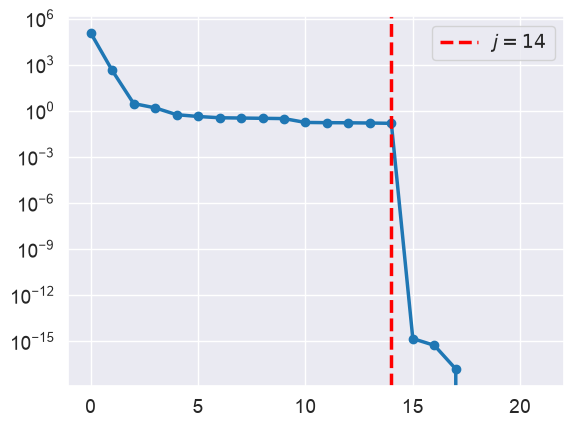

In [35]:
plt.semilogy(pca.explained_variance_, '-o')
plt.axvline(x=14, c='r', ls='--', label=r'$j=14$')
plt.legend()

The eigenvalues (explained variance) drops drastically after the 14<sup>th</sup> component. Moreover, the first component *drastically* Dominates the rest. In fact, we can plot a normalized view below:

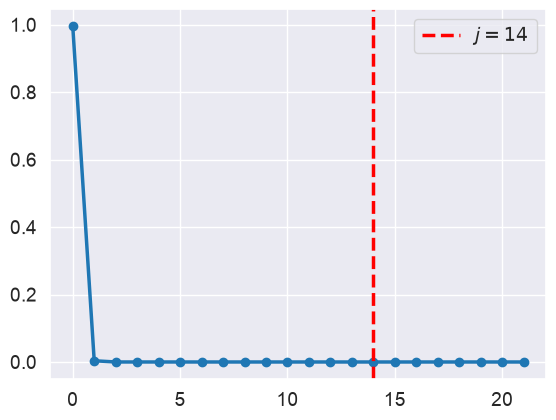

In [36]:
plt.plot(pca.explained_variance_ratio_, '-o')
plt.axvline(x=14, c='r', ls='--', label=r'$j=14$')
plt.legend()

## Principal Components

Let us look at what principal components we obtained.

Text(0.5, 1.0, 'Second Principal Component Axis')

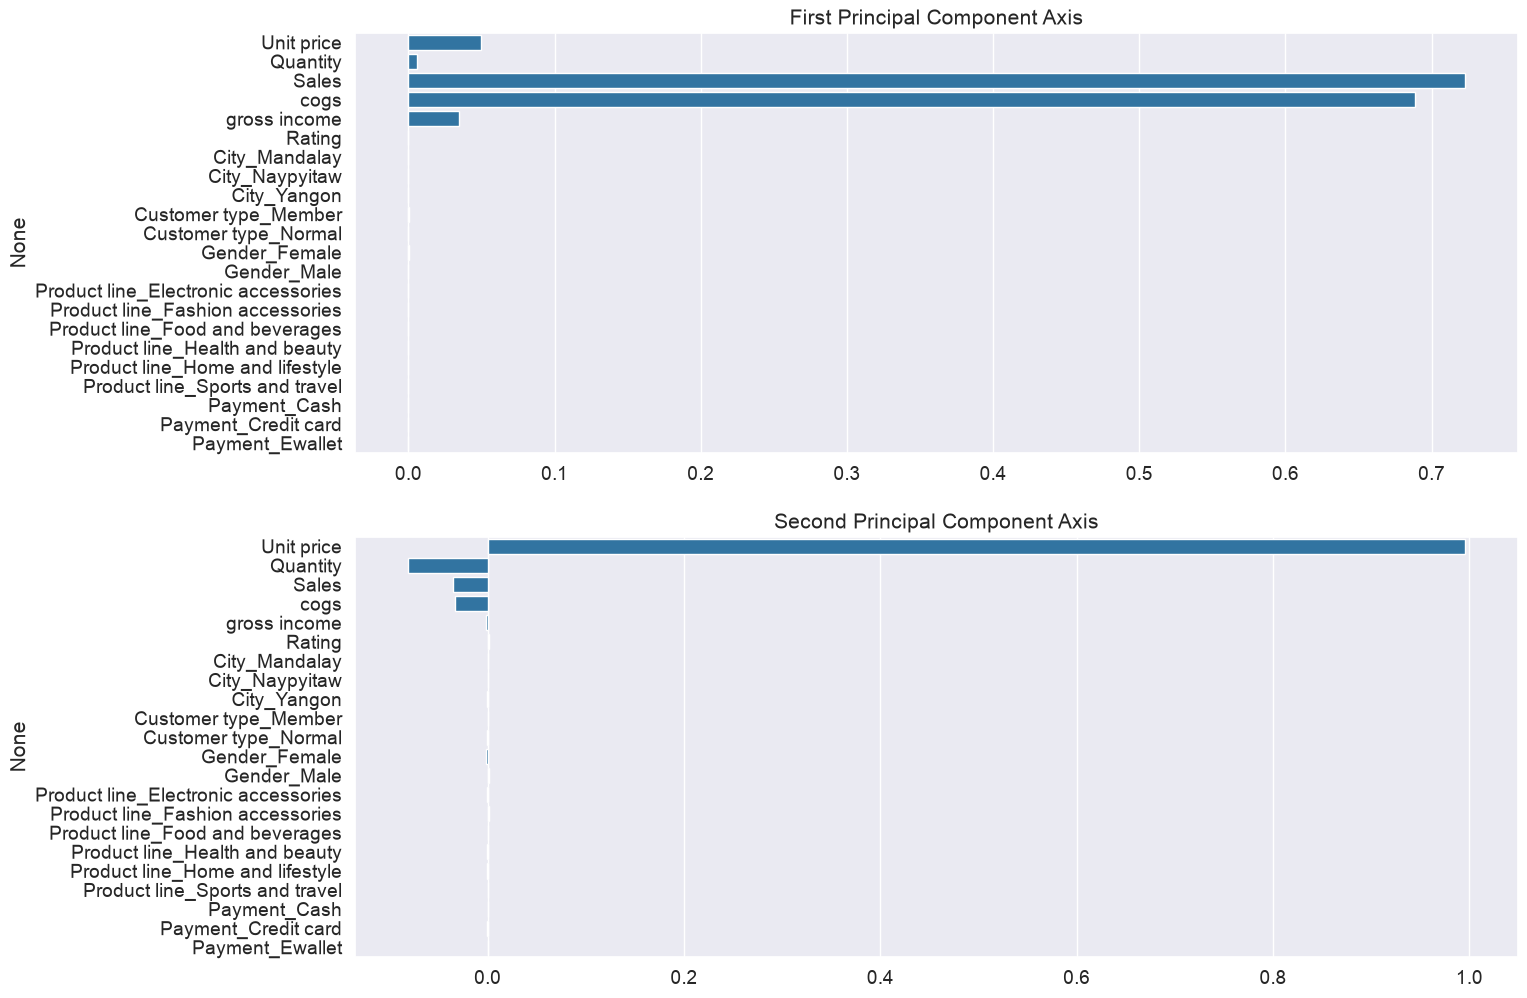

In [37]:
fig, ax = plt.subplots(2, 1, figsize=(15, 12))
sns.barplot(x=pca.components_[0], y=supermarket_data.columns, orient='h', ax=ax[0])
sns.barplot(x=pca.components_[1], y=supermarket_data.columns, orient='h', ax=ax[1])

ax[0].set_title('First Principal Component Axis')
ax[1].set_title('Second Principal Component Axis')

What's wrong? It appears that everything is dominated by either the total price, or the unit price!

This make sense, since these numbers are on the order of 10s or 100s, whereas the other features have much smaller values. Then, of course the majority of the variance is going to be dominated by these features. This is undesirable. 

To resolve this, let us use `sklearn.preprocessing` module to normalize the data.

In [38]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
supermarket_data_normalized = scaler.fit_transform(supermarket_data)

Then, we recheck our PCA results.

In [39]:
pca.fit(supermarket_data_normalized)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

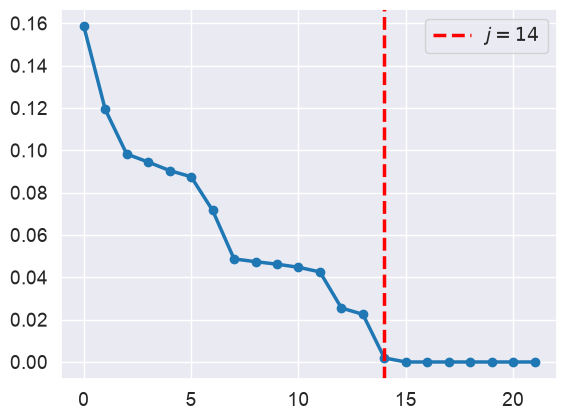

In [40]:
plt.plot(pca.explained_variance_ratio_, '-o')
plt.axvline(x=14, c='r', ls='--', label=r'$j=14$')
plt.legend()

Text(0.5, 1.0, 'Third Principal Component Axis')

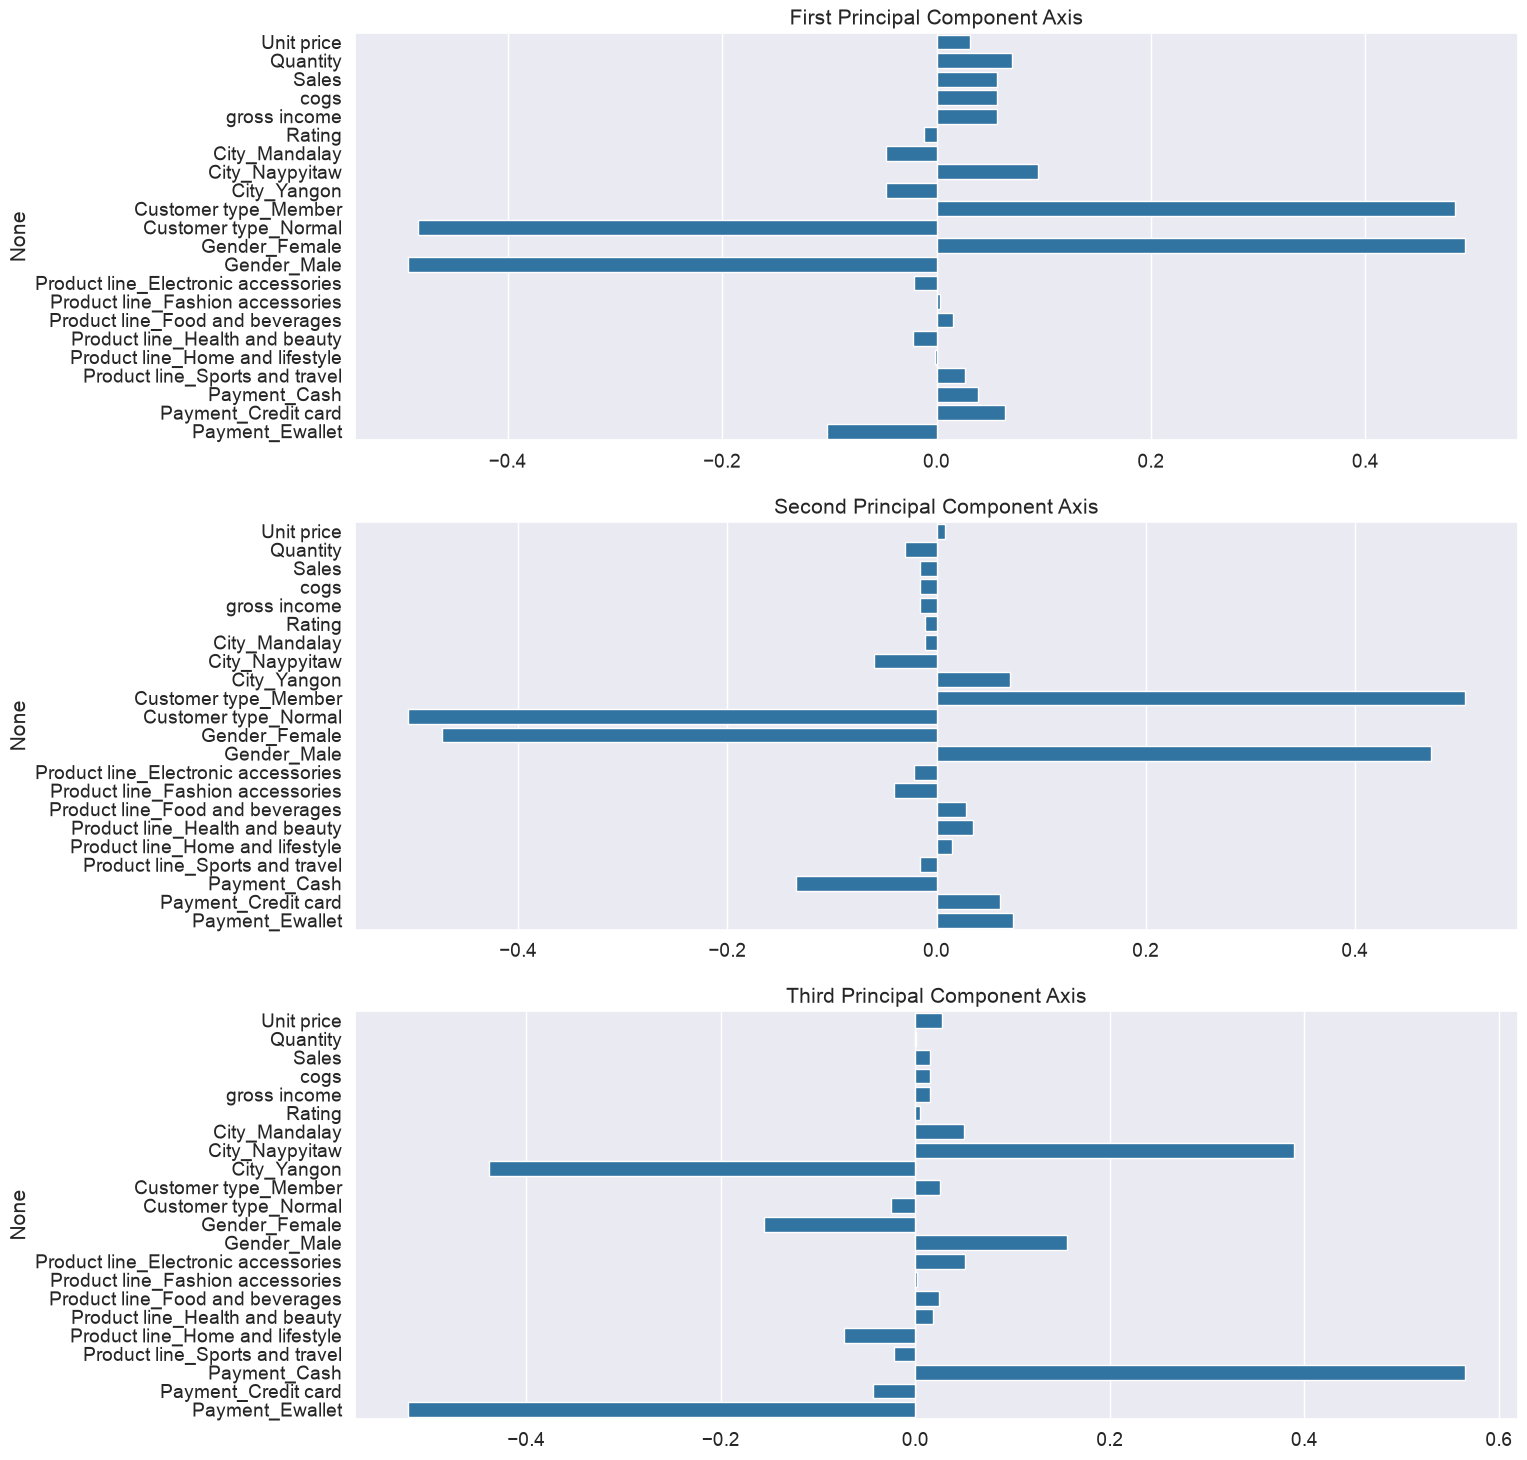

In [41]:
fig, ax = plt.subplots(3, 1, figsize=(15, 18))
sns.barplot(x=pca.components_[0], y=supermarket_data.columns, orient='h', ax=ax[0])
sns.barplot(x=pca.components_[1], y=supermarket_data.columns, orient='h', ax=ax[1])
sns.barplot(x=pca.components_[2], y=supermarket_data.columns, orient='h', ax=ax[2])

ax[0].set_title('First Principal Component Axis')
ax[1].set_title('Second Principal Component Axis')
ax[2].set_title('Third Principal Component Axis')

# PCA-based Recommender System

Now, let us demonstrate another usage of PCA. Instead of compression and reconstruction, we are going to use PCA to extract principal features, from which we can build simple recommendation systems.

For our dataset, we are going to use the [product SKUs](https://www.kaggle.com/cclark/product-item-data) from an apparel store hosted on kaggle.

In [ ]:
import kaggle
kaggle.api.authenticate()

kaggle.api.dataset_download_files(
    'cclark/product-item-data',
    path='./data',
    quiet=False,
    unzip=True
)

In [43]:
SKU_data = pd.read_csv('./data/sample-data.csv')

In [44]:
SKU_data

,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...
3,4,"Alpine guide pants - Skin in, climb ice, switc..."
4,5,"Alpine wind jkt - On high ridges, steep ice an..."
...,...,...
495,496,Cap 2 bottoms - Cut loose from the maddening c...
496,497,Cap 2 crew - This crew takes the edge off fick...
497,498,All-time shell - No need to use that morning T...
498,499,All-wear cargo shorts - All-Wear Cargo Shorts ...


Now, we are going to featurize the description. We will use the handy `TfidVectorizer` from `sklearn.feature_extraction.text`. This implements a bag-of-words embedding, meaning that we count the frequency of English words (and also symbols) at each sentence and have an abstract embedding of the counts. The actual implementation is slightly more complicated. You can read more about that [here](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction).

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [46]:
tf = TfidfVectorizer(analyzer='word', ngram_range=(1, 3), min_df=0.0, stop_words='english')
tfidf_matrix = tf.fit_transform(SKU_data['description'])
X = tfidf_matrix.todense()

Sample representation of 
Active sport boxer briefs - Skinning up Glory requires enough movement without your boxers deciding to poach their own route. The form-fitting Active Sport Boxer Briefs are made from breathable 93% polyester (71% recycled) fabric that's fast-wicking, dries quickly and has 7% spandex for stretch; the seamless waistband and soft leg edges won't roll or bind. The gusseted, flat-sewn 6" inseam (size M) is offset to prevent inner-thigh chafe. Fly-free with a smooth front panel. Recyclable through the Common Threads Recycling Program.<br><br><b>Details:</b><ul> <li>"Stretch mesh provides support, open-weave mesh for airflow, wicks efficiently, dries fast"</li> <li>Seamless construction</li> <li>"Flat-sewn, gusseted inseam is set forward to prevent inner-thigh chafe"</li> <li>Fly-free support</li> <li>"Inseam (size M) is 6"""</li></ul><br><br><b>Fabric: </b>"4.6-oz 93% polyester (71% recycled)/7% spandex, with moisture-wicking performance. Recyclable through the Comm

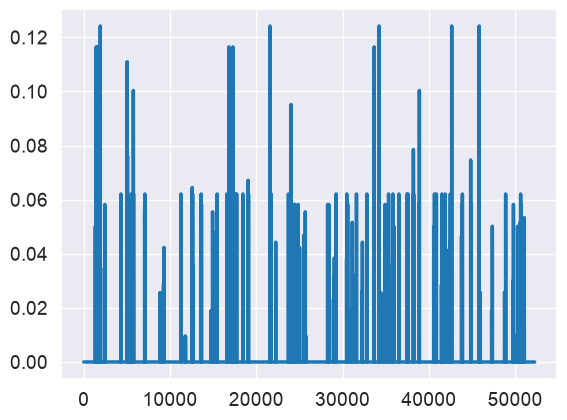

In [47]:
print(f'Sample representation of \n{SKU_data.iloc[1,1]}')
plt.plot(np.asarray(X)[1])

Let us now perform PCA on the extracted text features.

In [48]:
from sklearn.decomposition import PCA

In [49]:
pca = PCA(n_components=100)
pca.fit(np.asarray(X))

/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/utils/extmath.py:378: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/utils/extmath.py:378: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/utils/extmath.py:378: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/utils/extmath.py:379: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/utils/extmath.py:379: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/utils/extmath.py:379: RuntimeWarning: invalid value encountered in matmul
  Q, _ = no

/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/utils/extmath.py:383: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = qr_normalizer(A @ Q)
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/utils/extmath.py:383: RuntimeWarning: overflow encountered in matmul
  Q, _ = qr_normalizer(A @ Q)
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/utils/extmath.py:383: RuntimeWarning: invalid value encountered in matmul
  Q, _ = qr_normalizer(A @ Q)
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/utils/extmath.py:606: RuntimeWarning: divide by zero encountered in matmul
  B = Q.T @ M
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/utils/extmath.py:606: RuntimeWarning: overflow encountered in matmul
  B = Q.T @ M
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/utils/extmath.py:606: RuntimeWarning: invalid value encountered in matmul
  B = Q.T @ M
/Users/lihanw/.con

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",100
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SV

Visualize explained variance.

Text(0, 0.5, '$\\lambda_j$')

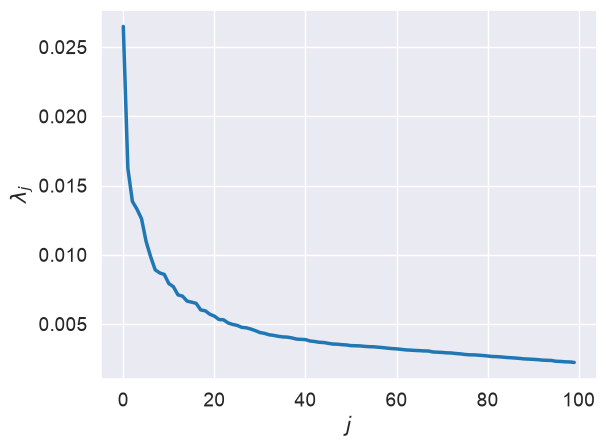

In [50]:
plt.plot(pca.explained_variance_)
plt.xlabel(r'$j$')
plt.ylabel(r'$\lambda_j$')

Let us now transform to latent space. This is a space of important features.

In [51]:
latents = pca.transform(np.asarray(X))

/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:159: RuntimeWarning: divide by zero encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components_.T
/Users/lihanw/.conda/envs/tf_m4/lib/python3.12/site-packages/sklearn/decomposition/_base.py:159: RuntimeWarning: overflow encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components

We can visualize the distribution of the data in the first three latent dimensions in different combinations

In [52]:
latents = pd.DataFrame(
    data=latents,
    columns=[f'Latent dim {i+1}' for i in range(latents.shape[-1])],
)

In [53]:
latents.shape

(500, 100)

<Axes: xlabel='Latent dim 1', ylabel='Latent dim 2'>

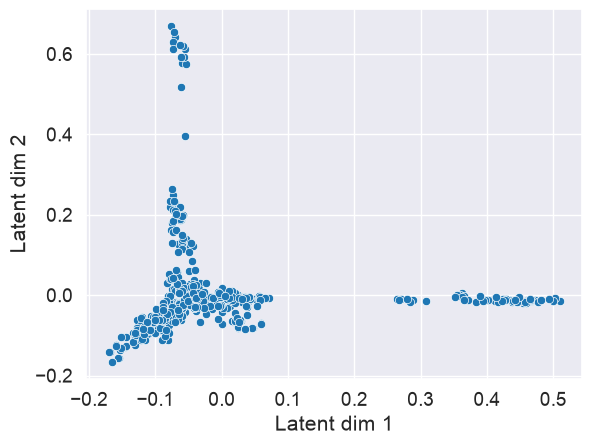

In [54]:
sns.scatterplot(
    x='Latent dim 1',
    y='Latent dim 2',
    data=latents,
)

<Axes: xlabel='Latent dim 1', ylabel='Latent dim 3'>

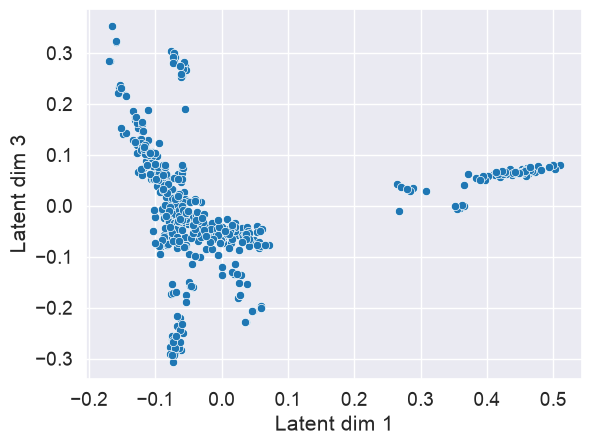

In [55]:
sns.scatterplot(
    x='Latent dim 1',
    y='Latent dim 3',
    data=latents,
)

<Axes: xlabel='Latent dim 2', ylabel='Latent dim 3'>

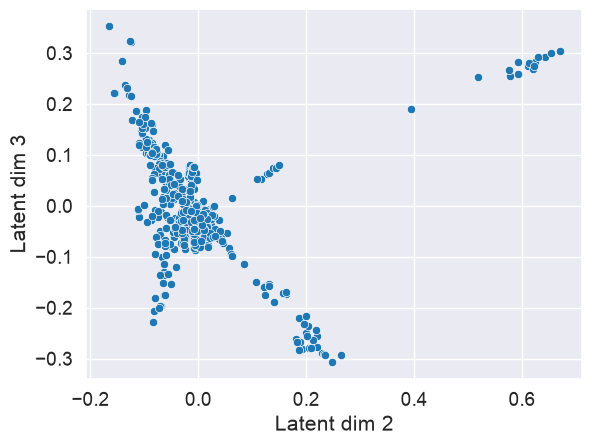

In [56]:
sns.scatterplot(
    x='Latent dim 2',
    y='Latent dim 3',
    data=latents,
)

Observe that we can already see some clustering behaviour, as should be expected since the merchandize descriptions overlap for similar items!

## Simple Recommender System

Based on the above observations, similar items should have similar principal component scores. So, let us simply take the *distance* in the latent space as a measure of similarity. 

This allows us to find, given an input sample item description, similar items to it. Consequently, we can make a recommender system from this! 

For any given input which represent an item a customer purchased, we will recommend some closest neighbour to this in the PCA latent space. Hopefully this gives similar items that the customer might want to look at. Interestingly, we can do this just from the SKU catalogue!

In [57]:
def recommend(bought_id, num_recommendation=7):
    """
    A simple recommender system using PCA
    """
    print(f'You bought:\n\n{SKU_data.description[bought_id][:100]}'+'...')
    
    # Compute PC scores using only first 10 components
    scores = latents.to_numpy()[:, :10]
    
    # Compute L^2 distances to the input Score
    distances = np.sum((scores - scores[bought_id, np.newaxis, :])**2, axis=1)
    
    # Return recommendations based on closest products in PCA latent space
    rec_ids = np.argsort(distances)[1:1+num_recommendation]
    rec_desc = SKU_data.description[rec_ids].to_numpy()
    print('\n\nWe recommend:\n')
    for i, d in zip(rec_ids, rec_desc):
        print(f'Id: {i} | Product: {d[:80]+"..."}')

In [58]:
recommend(100)

You bought:

Pataloha shirt - Early Hawaiian shirts were pitched as "postcards you can wear." We've been making o...


We recommend:

Id: 375 | Product: Polo shirt - Pulling on a polo opens the door to possibilities - the look gets y...
Id: 284 | Product: Ester top - Throw on the Ester Top for a quick surf check - its low-maintenance ...
Id: 181 | Product: Elsa tunic - The Elsa Tunic flourishes in heat-prone latitudes where its cool na...
Id: 180 | Product: Elsa top - When shade-seeking at Nine Palms starts to resemble a full-time job, ...
Id: 356 | Product: S/s casitas shirt - An ideal Saturday might include a hike-in surf at dawn, stal...
Id: 90 | Product: Migration hemp shirt - Summerweight and soft, the Migration represents an inspir...
Id: 224 | Product: S/s a/c shirt - Not even stifling Great Basin heat can overwhelm the born-to-chi...
